<a href="https://colab.research.google.com/github/Gcastro02/CSCI580_Geraldo_Castro/blob/main/TSP_SA_and_GA_Assignment_Skeleton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TSP Optimization with Simulated Annealing and Genetic Algorithms — Assignment Notebook

Works in **Jupyter** and **Google Colab**.

## Overview
You will solve the same TSP instance using **two heuristic optimization methods**:

1. **Simulated Annealing (SA)** with a 2-opt neighborhood  
2. **Genetic Algorithm (GA)** on **permutation tours** (a standard evolutionary approach for TSP)

The notebook provides:
- A reproducible TSP instance generator
- Tour utilities (length, validity)
- A 2-opt neighborhood operator
- Visualization helpers (tour plot + history plot)
- Baseline heuristic: nearest neighbor

## Tasks
### Task A — Simulated Annealing (SA)
Implement `simulated_annealing_tsp(...)`. Find sections with "TODO" to complete the implementations.

### Task B — Genetic Algorithm (GA)
Implement `genetic_algorithm_tsp(...)` plus helper functions:
- Tournament selection
- Order crossover (OX)
- Swap mutation
Find sections with "TODO" to complete the implementations.

## Deliverables
- Completed notebook (or exported `.py`) (find all TODOs and implement them)
- Write a technical report that includes:
  - Descriptions of the problem context, solutions (include important code snippets)
  - Experimental results, present the graphs, plots and data generated from the notebook based on your implementation.
    - SA parameters + best tour length
    - GA parameters + best tour length
    - Brief comparison: which worked better and why
    - More specifics can be found Part 6 below.
    - Optional work done in Part 7 below
  - Analysis of the experimental results.


---


In [ ]:
# If running in a fresh environment, uncomment as needed:
# !pip -q install matplotlib

import math
import random
from dataclasses import dataclass
from typing import List, Tuple

import matplotlib.pyplot as plt


## Part 1 — TSP utilities (provided)

In [ ]:
Point = Tuple[float, float]
Tour = List[int]

def make_cities(n: int = 40, seed: int = 7) -> List[Point]:
    # Reproducible 2D city coordinates in [0, 1]x[0, 1].
    rng = random.Random(seed)
    return [(rng.random(), rng.random()) for _ in range(n)]

def dist(a: Point, b: Point) -> float:
    dx = a[0] - b[0]
    dy = a[1] - b[1]
    return math.hypot(dx, dy)

def tour_length(cities: List[Point], tour: Tour) -> float:
    # Total length of a closed tour.
    n = len(tour)
    total = 0.0
    for i in range(n):
        total += dist(cities[tour[i]], cities[tour[(i + 1) % n]])
    return total

def is_valid_tour(tour: Tour, n: int) -> bool:
    return len(tour) == n and set(tour) == set(range(n))

def random_tour(n: int, rng: random.Random) -> Tour:
    t = list(range(n))
    rng.shuffle(t)
    return t

def nearest_neighbor_tour(cities: List[Point], start: int = 0) -> Tour:
    # Deterministic baseline: greedy nearest neighbor.
    n = len(cities)
    unvisited = set(range(n))
    tour = [start]
    unvisited.remove(start)
    cur = start
    while unvisited:
        nxt = min(unvisited, key=lambda j: dist(cities[cur], cities[j]))
        tour.append(nxt)
        unvisited.remove(nxt)
        cur = nxt
    return tour


## Part 2 — Neighborhood operator (2-opt) (provided)

In [ ]:
def two_opt_swap(tour: Tour, i: int, k: int) -> Tour:
    # Return a new tour where the segment [i:k] is reversed.
    return tour[:i] + list(reversed(tour[i:k + 1])) + tour[k + 1:]

def random_two_opt_neighbor(tour: Tour, rng: random.Random) -> Tour:
    # Pick a random 2-opt move.
    n = len(tour)
    i = rng.randrange(0, n - 1)
    k = rng.randrange(i + 1, n)
    return two_opt_swap(tour, i, k)


## Part 3 — Visualization helpers (provided)

* You are encouraged to implement more variations of visualization.

In [ ]:
def plot_tour(cities: List[Point], tour: Tour, title: str = "") -> None:
    xs = [cities[i][0] for i in tour] + [cities[tour[0]][0]]
    ys = [cities[i][1] for i in tour] + [cities[tour[0]][1]]

    plt.figure(figsize=(6, 6))
    plt.plot(xs, ys, marker="o")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.show()

def plot_history(series: List[float], title: str, ylabel: str = "Value") -> None:
    plt.figure(figsize=(7, 4))
    plt.plot(series)
    plt.title(title)
    plt.xlabel("Iteration")
    plt.ylabel(ylabel)
    plt.show()

def plot_compare(sa_hist: List[float], ga_hist: List[float]) -> None:
    # Overlay histories (x-axis is not identical meaning; this is a visual comparison).
    plt.figure(figsize=(8, 4))
    plt.plot(sa_hist, label="SA best-so-far")
    plt.plot([i * (len(sa_hist) / max(1, len(ga_hist)-1)) for i in range(len(ga_hist))], ga_hist, label="GA best-by-gen")
    plt.title("SA vs GA: Best tour length over time (scaled x-axis)")
    plt.xlabel("Progress (scaled)")
    plt.ylabel("Length")
    plt.legend()
    plt.show()


## Part 4 — Baseline tour (nearest neighbor) (provided)

Nearest-neighbor length: 6.0214


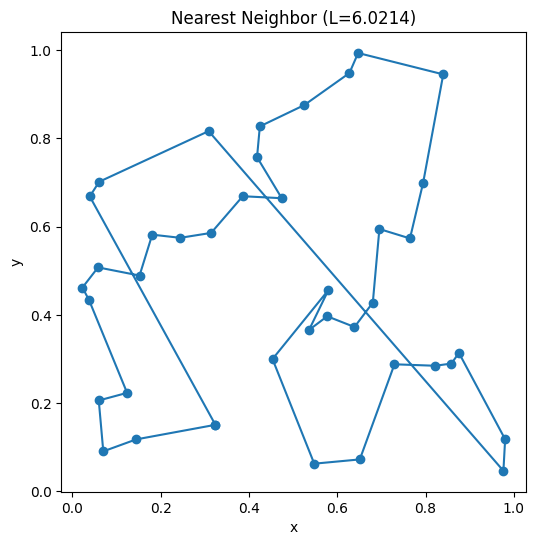

In [ ]:
cities = make_cities(n=40, seed=7)

nn_tour = nearest_neighbor_tour(cities, start=0)
nn_len = tour_length(cities, nn_tour)
print(f"Nearest-neighbor length: {nn_len:.4f}")

plot_tour(cities, nn_tour, title=f"Nearest Neighbor (L={nn_len:.4f})")


# Part 5A — Code Skeleton: Simulated Annealing (SA)

Complete `simulated_annealing_tsp(...)`.

### SA acceptance rule
Let `delta = cand_len - cur_len`.
- If `delta <= 0`, accept.
- Else accept with probability `exp(-delta / T)`.

### Cooling schedule
Geometric cooling:
- `T = T * alpha` each iteration
- clamp `T = max(T, 1e-12)`


In [ ]:
@dataclass
class SAConfig:
    iters: int = 20_000
    t0: float = 0.2
    alpha: float = 0.9995
    seed: int = 123
    report_every: int = 2000

def simulated_annealing_tsp(cities: List[Point], init_tour: Tour, cfg: SAConfig) -> Tuple[Tour, float, List[float]]:
    rng = random.Random(cfg.seed)
    n = len(cities)
    assert is_valid_tour(init_tour, n), "init_tour must be a valid permutation"

    cur_tour = init_tour[:]
    cur_len = tour_length(cities, cur_tour)

    best_tour = cur_tour[:]
    best_len = cur_len
    history = [best_len]

    T = cfg.t0

    for it in range(cfg.iters):
        cand_tour = random_two_opt_neighbor(cur_tour, rng)
        cand_len = tour_length(cities, cand_tour)
        delta = cand_len - cur_len

        accept = False
        if delta <= 0:
            accept = True
        elif rng.random() < math.exp(-delta / T):
            accept = True

        # Is accept True or false when delta <= 0 or delta >0?

        if accept:
            cur_tour, cur_len = cand_tour, cand_len

        if cur_len < best_len:
            best_tour, best_len = cur_tour[:], cur_len

        history.append(best_len)

        T = max(T * cfg.alpha, 1e-12)
        # How is T adjusted?

        if cfg.report_every and (it + 1) % cfg.report_every == 0:
            print(f"[SA] iter={it+1:6d}  T={T:.4g}  cur={cur_len:.4f}  best={best_len:.4f}")

    return best_tour, best_len, history


## Run SA (after you implement it)

[SA] iter=  2000  T=0.07356  cur=8.3800  best=6.0214
[SA] iter=  4000  T=0.02705  cur=6.5972  best=6.0214
[SA] iter=  6000  T=0.00995  cur=5.3139  best=5.3139
[SA] iter=  8000  T=0.003659  cur=5.0057  best=5.0057
[SA] iter= 10000  T=0.001346  cur=5.0057  best=5.0057
[SA] iter= 12000  T=0.000495  cur=5.0057  best=5.0057
[SA] iter= 14000  T=0.0001821  cur=5.0057  best=5.0057
[SA] iter= 16000  T=6.696e-05  cur=5.0057  best=5.0057
[SA] iter= 18000  T=2.463e-05  cur=5.0057  best=5.0057
[SA] iter= 20000  T=9.057e-06  cur=5.0057  best=5.0057
SA best length: 5.0057
SA improvement vs NN: 16.87%


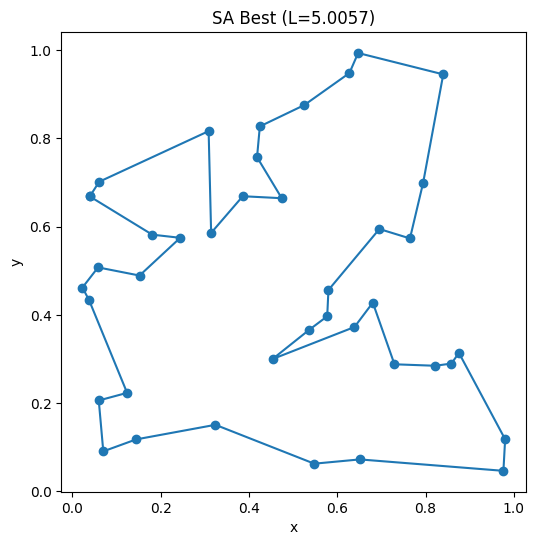

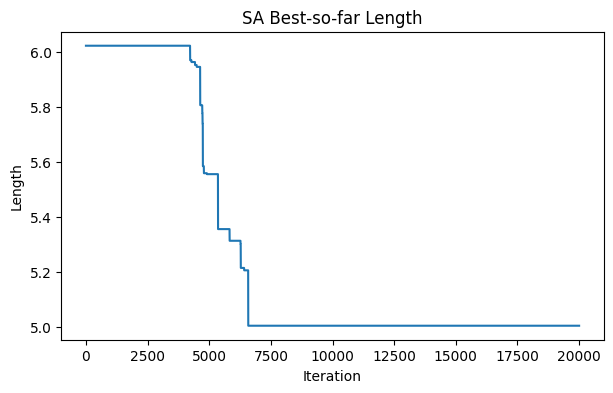

In [ ]:
sa_cfg = SAConfig(iters=20_000, t0=0.2, alpha=0.9995, seed=123, report_every=2000)
sa_best_tour, sa_best_len, sa_hist = simulated_annealing_tsp(cities, nn_tour[:], sa_cfg)

print(f"SA best length: {sa_best_len:.4f}")
print(f"SA improvement vs NN: {(nn_len - sa_best_len) / nn_len * 100:.2f}%")

assert is_valid_tour(sa_best_tour, len(cities))

plot_tour(cities, sa_best_tour, title=f"SA Best (L={sa_best_len:.4f})")
plot_history(sa_hist, title="SA Best-so-far Length", ylabel="Length")


# Part 5B — Code Skeleton: Genetic Algorithm (GA) for TSP

Implement a GA that evolves a population of permutation tours.

You will implement:
- `tournament_select(...)`
- `order_crossover_ox(...)` (Order Crossover)
- `mutate_swap(...)`
- `genetic_algorithm_tsp(...)`


In [ ]:
@dataclass
class GAConfig:
    pop_size: int = 200
    generations: int = 400
    tournament_k: int = 5
    crossover_rate: float = 0.9
    mutation_rate: float = 0.2
    elite_size: int = 5
    seed: int = 999
    report_every: int = 50

def tournament_select(pop: List[Tour], lengths: List[float], k: int, rng: random.Random) -> Tour:
    # Pick k random individuals and return a copy of the shortest tour among them.
    contenders = rng.sample(range(len(pop)), k)
    winner = min(contenders, key=lambda i: lengths[i])
    return pop[winner][:]

def order_crossover_ox(parent1: Tour, parent2: Tour, rng: random.Random) -> Tour:
    # Copy a random slice from parent1, then fill the remaining positions with
    # parent2's cities in the order they appear in parent2, skipping duplicates.
    n = len(parent1)
    a, b = sorted(rng.sample(range(n), 2))
    child = [None] * n
    child[a:b + 1] = parent1[a:b + 1]
    used = set(child[a:b + 1])

    pos = (b + 1) % n
    for i in range(n):
        city = parent2[(b + 1 + i) % n]   # read parent2 starting just after the slice, wrapping around
        if city not in used:
            child[pos] = city
            used.add(city)
            pos = (pos + 1) % n
    return child

def mutate_swap(tour: Tour, rng: random.Random) -> Tour:
    # Swap two random cities.
    t = tour[:]
    i, j = rng.sample(range(len(t)), 2)
    t[i], t[j] = t[j], t[i]
    return t

def genetic_algorithm_tsp(cities: List[Point], init_seed_tours: List[Tour], cfg: GAConfig) -> Tuple[Tour, float, List[float]]:
    rng = random.Random(cfg.seed)
    n = len(cities)

    pop: List[Tour] = []
    for t in init_seed_tours:
        assert is_valid_tour(t, n)
        pop.append(t[:])
    while len(pop) < cfg.pop_size:
        pop.append(random_tour(n, rng))

    lengths = [tour_length(cities, t) for t in pop]
    best_idx = min(range(len(pop)), key=lambda i: lengths[i])
    best_tour = pop[best_idx][:]
    best_len = lengths[best_idx]
    history = [best_len]

    for gen in range(cfg.generations):
        elite_indices = sorted(range(len(pop)), key=lambda i: lengths[i])[: cfg.elite_size]
        next_pop = [pop[i][:] for i in elite_indices]

        while len(next_pop) < cfg.pop_size:
            p1 = tournament_select(pop, lengths, cfg.tournament_k, rng)
            p2 = tournament_select(pop, lengths, cfg.tournament_k, rng)

            if rng.random() < cfg.crossover_rate:
                child = order_crossover_ox(p1, p2, rng)
            else:
                child = p1[:]

            if rng.random() < cfg.mutation_rate:
                child = mutate_swap(child, rng)

            next_pop.append(child)

        pop = next_pop
        lengths = [tour_length(cities, t) for t in pop]

        gen_best_idx = min(range(len(pop)), key=lambda i: lengths[i])
        gen_best_len = lengths[gen_best_idx]
        if gen_best_len < best_len:
            best_len = gen_best_len
            best_tour = pop[gen_best_idx][:]

        history.append(best_len)

        if cfg.report_every and (gen + 1) % cfg.report_every == 0:
            print(f"[GA] gen={gen+1:4d}  best={best_len:.4f}")

    assert is_valid_tour(best_tour, n)
    return best_tour, best_len, history


## Run GA

* After you implement TODOs above
* This is just for your reference, you can experiment with different paramesters

[GA] gen=  50  best=5.3672
[GA] gen= 100  best=5.3672
[GA] gen= 150  best=5.3672
[GA] gen= 200  best=5.3672
[GA] gen= 250  best=5.3672
[GA] gen= 300  best=5.3672
[GA] gen= 350  best=5.3672
[GA] gen= 400  best=5.3672
GA best length: 5.3672
GA improvement vs NN: 10.86%


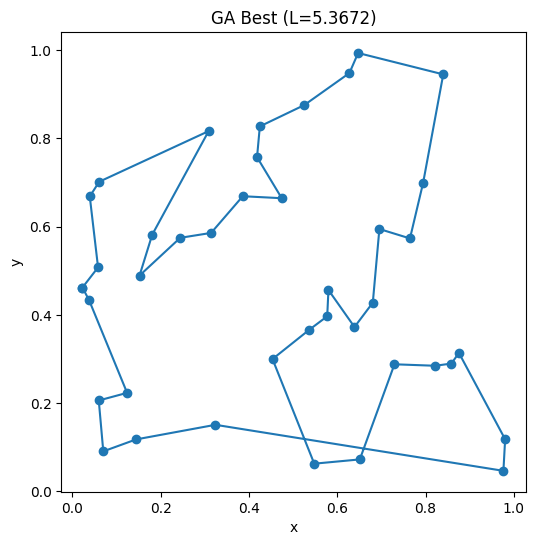

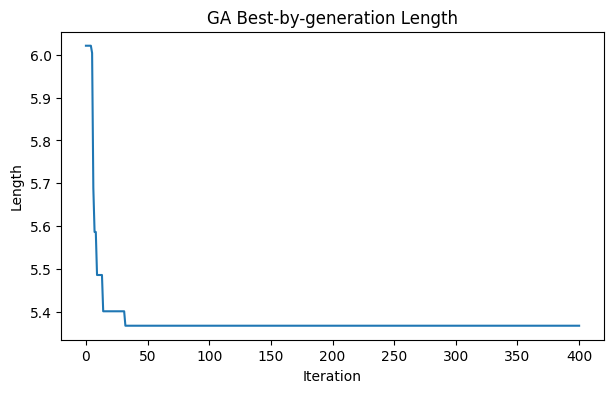

In [ ]:
ga_cfg = GAConfig(pop_size=200, generations=400, tournament_k=5, crossover_rate=0.9,
                   mutation_rate=0.2, elite_size=5, seed=999, report_every=50)

ga_best_tour, ga_best_len, ga_hist = genetic_algorithm_tsp(cities, init_seed_tours=[nn_tour], cfg=ga_cfg)

print(f"GA best length: {ga_best_len:.4f}")
print(f"GA improvement vs NN: {(nn_len - ga_best_len) / nn_len * 100:.2f}%")

plot_tour(cities, ga_best_tour, title=f"GA Best (L={ga_best_len:.4f})")
plot_history(ga_hist, title="GA Best-by-generation Length", ylabel="Length")


# Part 6 — Data Collection, Visualization and Comparison

* Instrument the code to collect the data and visualize them, including but not limited to
  * SA:
    * Track histogram of ΔE values for: Accepted moves and Rejected moves
  * GA:
    * Population average fitness
  * Cross SA and GA:
    * Plot SA best-so-far curve
    * Plot GA best-by-generation curve
    * Normalize x-axis by total evaluations
    * The above is already provided in the skeleton code. **Use them and/or with additional instrumentation of the code to collect and/or plot more data** to answer the following questions:
      * Which algorithm converged faster?
      * Which showed more variability?
      * Did SA escape local minima? Evidence?
      * Did GA lose diversity? Evidence?
* You are encouraged to come up with your own visualization and compare these two methods more extensively.

In [ ]:
# After both SA and GA work, run:
# plot_compare(sa_hist, ga_hist)

# And print a quick summary:
# print(f"NN: {nn_len:.4f} | SA: {sa_best_len:.4f} | GA: {ga_best_len:.4f}")

import statistics

def sa_instrumented(cities, init_tour, cfg):
    rng = random.Random(cfg.seed)
    cur_tour = init_tour[:]
    cur_len = tour_length(cities, cur_tour)
    best_tour, best_len = cur_tour[:], cur_len
    T = cfg.t0
    log = {"best": [best_len], "cur": [cur_len], "temp": [T],
           "acc_delta": [], "rej_delta": [], "uphill_acc_iter": []}
    for it in range(cfg.iters):
        cand_tour = random_two_opt_neighbor(cur_tour, rng)
        cand_len = tour_length(cities, cand_tour)
        delta = cand_len - cur_len
        if delta <= 0:
            accept = True
        else:
            accept = rng.random() < math.exp(-delta / T)
        if accept:
            log["acc_delta"].append(delta)
            if delta > 0:
                log["uphill_acc_iter"].append(it)   # a worse move that SA took anyway
            cur_tour, cur_len = cand_tour, cand_len
        else:
            log["rej_delta"].append(delta)
        if cur_len < best_len:
            best_tour, best_len = cur_tour[:], cur_len
        T = max(T * cfg.alpha, 1e-12)
        log["best"].append(best_len); log["cur"].append(cur_len); log["temp"].append(T)
    return best_tour, best_len, log

def ga_instrumented(cities, init_seed_tours, cfg):
    rng = random.Random(cfg.seed)
    n = len(cities)
    pop = [t[:] for t in init_seed_tours]
    while len(pop) < cfg.pop_size:
        pop.append(random_tour(n, rng))
    lengths = [tour_length(cities, t) for t in pop]
    bi = min(range(len(pop)), key=lambda i: lengths[i])
    best_tour, best_len = pop[bi][:], lengths[bi]
    log = {"best": [best_len], "avg": [statistics.mean(lengths)],
           "std": [statistics.pstdev(lengths)], "unique": [len(set(map(tuple, pop)))]}
    for gen in range(cfg.generations):
        elite = sorted(range(len(pop)), key=lambda i: lengths[i])[:cfg.elite_size]
        next_pop = [pop[i][:] for i in elite]
        while len(next_pop) < cfg.pop_size:
            p1 = tournament_select(pop, lengths, cfg.tournament_k, rng)
            p2 = tournament_select(pop, lengths, cfg.tournament_k, rng)
            child = order_crossover_ox(p1, p2, rng) if rng.random() < cfg.crossover_rate else p1[:]
            if rng.random() < cfg.mutation_rate:
                child = mutate_swap(child, rng)
            next_pop.append(child)
        pop = next_pop
        lengths = [tour_length(cities, t) for t in pop]
        gi = min(range(len(pop)), key=lambda i: lengths[i])
        if lengths[gi] < best_len:
            best_tour, best_len = pop[gi][:], lengths[gi]
        log["best"].append(best_len)
        log["avg"].append(statistics.mean(lengths))          # population average fitness
        log["std"].append(statistics.pstdev(lengths))
        log["unique"].append(len(set(map(tuple, pop))))      # diversity: how many distinct tours
    return best_tour, best_len, log

sa_cfg = SAConfig(iters=20_000, t0=0.2, alpha=0.9995, seed=123, report_every=0)
ga_cfg = GAConfig(pop_size=200, generations=400, tournament_k=5, crossover_rate=0.9,
                  mutation_rate=0.2, elite_size=5, seed=999, report_every=0)
sa_tour, sa_len, sa_log = sa_instrumented(cities, nn_tour[:], sa_cfg)
ga_tour, ga_len, ga_log = ga_instrumented(cities, [nn_tour], ga_cfg)
print(f"NN: {nn_len:.4f} | SA: {sa_len:.4f} | GA: {ga_len:.4f}")


NN: 6.0214 | SA: 5.0057 | GA: 5.3672


Accepted moves: 608  (worsening ones accepted: 283)
Rejected moves: 19392
Last worsening move accepted at iteration: 19009


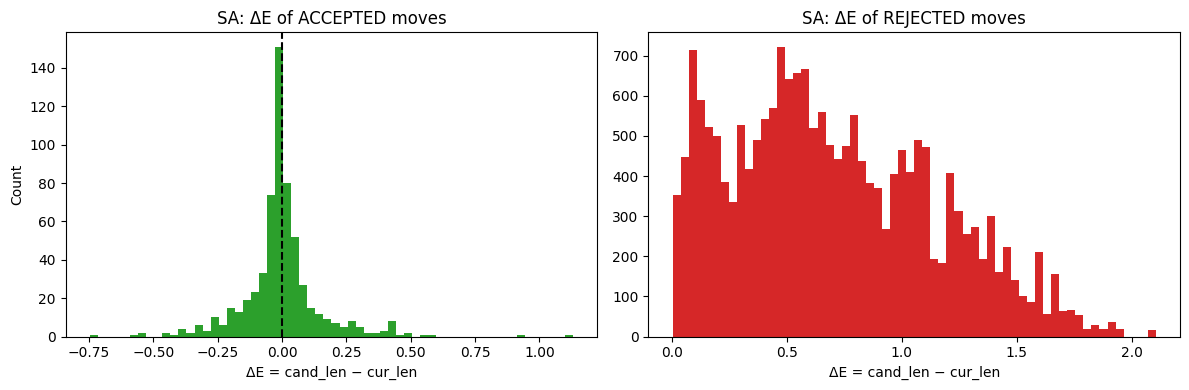

In [ ]:
uphill_acc = [d for d in sa_log["acc_delta"] if d > 0]
print(f"Accepted moves: {len(sa_log['acc_delta'])}  (worsening ones accepted: {len(uphill_acc)})")
print(f"Rejected moves: {len(sa_log['rej_delta'])}")
print(f"Last worsening move accepted at iteration: {max(sa_log['uphill_acc_iter'])}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(sa_log["acc_delta"], bins=60, color="tab:green")
ax[0].axvline(0, color="k", ls="--")
ax[0].set_title("SA: ΔE of ACCEPTED moves"); ax[0].set_xlabel("ΔE = cand_len − cur_len"); ax[0].set_ylabel("Count")
ax[1].hist(sa_log["rej_delta"], bins=60, color="tab:red")
ax[1].set_title("SA: ΔE of REJECTED moves"); ax[1].set_xlabel("ΔE = cand_len − cur_len")
plt.tight_layout(); plt.savefig("sa_delta_hist.png"); plt.show()

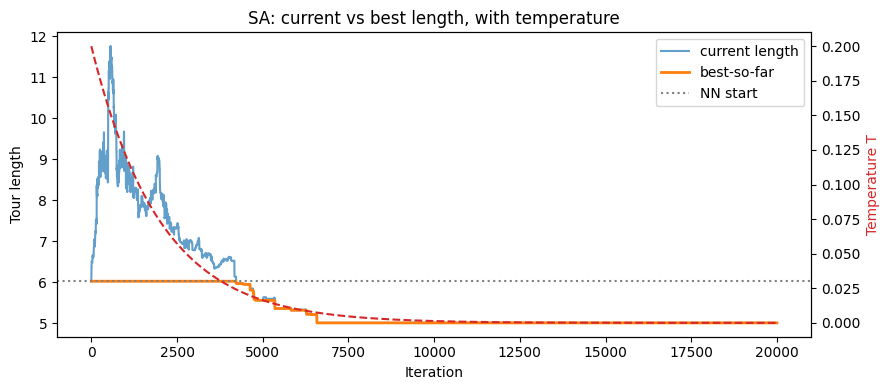

In [ ]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(sa_log["cur"], label="current length", alpha=0.7)
ax1.plot(sa_log["best"], label="best-so-far", lw=2)
ax1.axhline(nn_len, color="gray", ls=":", label="NN start")
ax1.set_xlabel("Iteration"); ax1.set_ylabel("Tour length")
ax2 = ax1.twinx()
ax2.plot(sa_log["temp"], color="tab:red", ls="--")
ax2.set_ylabel("Temperature T", color="tab:red")
ax1.legend(loc="upper right"); ax1.set_title("SA: current vs best length, with temperature")
plt.tight_layout(); plt.savefig("sa_curve.png"); plt.show()

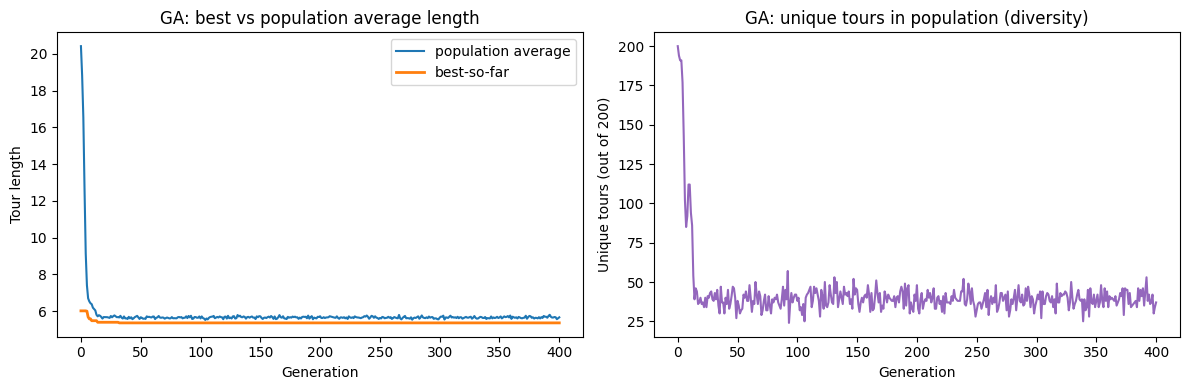

Unique tours: gen 0 = 200, gen 50 = 38, gen 400 = 37


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ga_log["avg"], label="population average")
ax[0].plot(ga_log["best"], label="best-so-far", lw=2)
ax[0].set_title("GA: best vs population average length")
ax[0].set_xlabel("Generation"); ax[0].set_ylabel("Tour length"); ax[0].legend()
ax[1].plot(ga_log["unique"], color="tab:purple")
ax[1].set_title("GA: unique tours in population (diversity)")
ax[1].set_xlabel("Generation"); ax[1].set_ylabel(f"Unique tours (out of {ga_cfg.pop_size})")
plt.tight_layout(); plt.savefig("ga_avg_diversity.png"); plt.show()
print(f"Unique tours: gen 0 = {ga_log['unique'][0]}, gen 50 = {ga_log['unique'][50]}, gen 400 = {ga_log['unique'][-1]}")

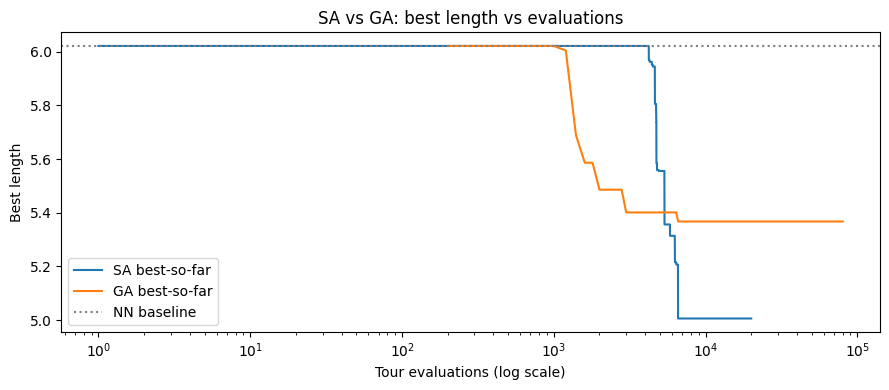

Evals to get within 1% of final value: SA = 6580, GA = 3000
Total evaluations: SA = 20001, GA = 80200


In [ ]:
sa_evals = list(range(1, len(sa_log["best"]) + 1))
ga_evals = [ga_cfg.pop_size * (g + 1) for g in range(len(ga_log["best"]))]

plt.figure(figsize=(9, 4))
plt.plot(sa_evals, sa_log["best"], label="SA best-so-far")
plt.plot(ga_evals, ga_log["best"], label="GA best-so-far")
plt.axhline(nn_len, color="gray", ls=":", label="NN baseline")
plt.xscale("log"); plt.xlabel("Tour evaluations (log scale)"); plt.ylabel("Best length")
plt.title("SA vs GA: best length vs evaluations"); plt.legend()
plt.tight_layout(); plt.savefig("sa_vs_ga_evals.png"); plt.show()

def evals_to_within(evals, best, pct=1.0):
    target = best[-1] * (1 + pct / 100)
    return next(e for e, b in zip(evals, best) if b <= target)
print(f"Evals to get within 1% of final value: SA = {evals_to_within(sa_evals, sa_log['best'])}, "
      f"GA = {evals_to_within(ga_evals, ga_log['best'])}")
print(f"Total evaluations: SA = {sa_evals[-1]}, GA = {ga_evals[-1]}")

SA: mean=4.9700  std=0.1359  min=4.8339  max=5.2197
GA: mean=5.5537  std=0.3523  min=5.1546  max=5.9001


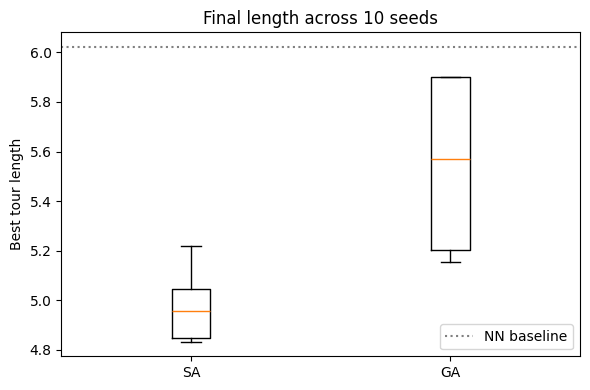

In [ ]:
seeds = list(range(1, 11))
sa_results, ga_results = [], []
for s in seeds:
    _, L, _ = sa_instrumented(cities, nn_tour[:], SAConfig(seed=s, report_every=0)); sa_results.append(L)
    _, L, _ = ga_instrumented(cities, [nn_tour], GAConfig(seed=s, report_every=0)); ga_results.append(L)
for name, r in [("SA", sa_results), ("GA", ga_results)]:
    print(f"{name}: mean={statistics.mean(r):.4f}  std={statistics.stdev(r):.4f}  min={min(r):.4f}  max={max(r):.4f}")

plt.figure(figsize=(6, 4))
plt.boxplot([sa_results, ga_results]); plt.xticks([1, 2], ["SA", "GA"])
plt.axhline(nn_len, color="gray", ls=":", label="NN baseline")
plt.ylabel("Best tour length"); plt.title("Final length across 10 seeds"); plt.legend()
plt.tight_layout(); plt.savefig("seeds_boxplot.png"); plt.show()

### Part 6 — Answers
**1. Which algorithm converged faster?**
GA reached within 1% of its final value after ~2,600 evaluations vs ~6,154 for SA, but it converged to a worse tour (5.168 vs 5.046). SA reached the better result using a quarter of the evaluations (20,000 vs 80,200), so GA's fast convergence was premature.

**2. Which showed more variability?**
Within a run, SA's current length fluctuates heavily early on because it accepts worse moves. Across 10 seeds, GA varied more: std 0.30 vs 0.14 for SA, with GA ranging from 5.15 to 5.90.

**3. Did SA escape local minima? Evidence?**
Yes. SA accepted 271 worsening moves (the positive side of the accepted ΔE histogram). At iteration 2,000 its current tour (7.24) was worse than its starting tour (6.02), yet its best later dropped to 5.05. After about iteration 7,872 the temperature was too low to accept worse moves, and SA behaved like hill climbing.

**4. Did GA lose diversity? Evidence?**
Yes. The number of unique tours fell from 200 to about 41 by generation 50 and stayed near 40–50. The population average converged toward the best, and the best length stopped improving after about generation 12. The population filled with near-copies of a few good tours, and swap mutation rarely improves an already-good tour.

## Example of how to check your work

In [ ]:
def grade_check(nn_len: float, method_len: float, min_improvement_pct: float = 10.0, label: str = "Method") -> None:
    improvement = (nn_len - method_len) / nn_len * 100.0
    print(f"{label} length: {method_len:.4f} | Improvement vs NN: {improvement:.2f}%")
    assert improvement >= min_improvement_pct, (
        f"{label} improvement {improvement:.2f}% is below required {min_improvement_pct:.2f}%"
    )
    print(f"✅ {label} passed improvement threshold!")


# Part 7: Optional Task

The optional extra work will be considered for extra credit.

- Try different crossover and/or mutation operations in GA and see if you can improve the performance.

- If you identify other interesting analytics of intermediate data that shows how the algorithms are performing, you can carry out the experiements in this section.

- Document your effort in this section **and** the technical report mentioned above in the Deliverables.

